# 04 — Knowledge Graph Construction & Drug Target Discovery

**Pipeline Step 4 of 5**

Constructs a **Micro-Clinical Knowledge Graph (Micro-CKG)** that translates
spatially validated biomarkers from the **PSAPP Alzheimer's disease mouse
model** (Notebook 02) into a clinically actionable knowledge network.

### Disease Context
The PSAPP transgenic mouse co-expresses mutant human APP (Swedish) and
PSEN1 (M146L), producing progressive amyloid-β (Aβ) plaque deposition,
neuroinflammation, and hippocampal neurodegeneration — recapitulating key
features of familial Alzheimer’s disease.  Notebook 02’s Stabl feature
selection identified 33 biomarkers that reliably discriminate AD from WT
spots.  The top AD-relevant genes cluster into three data-driven themes:

| Theme | Key gene(s) | AD relevance |
|---|---|---|
| **Aβ synaptic toxicity** | *Prnp*, *Ngfr*, *Syt2*, *Sv2c* | Aβ-oligomer receptor, p75^NTR apoptosis, synaptic vesicle loss |
| **Monoaminergic neurodegeneration** | *Th*, *Oxt*, *Pmch* | Locus coeruleus DA/NE loss, hypothalamic circuit disruption |
| **Stress & lipid signalling** | *Cdc42ep1*, *Foxo4*, *Cyp27a1* | Direct AD association (OpenTargets), oxidative senescence, oxysterol metabolism |

This notebook asks: **which human drugs, diseases, and pathways connect
to these Stabl-selected biomarkers, and can the KG reveal druggable
intervention points?**

### Pipeline
1. **Leiden clustering** of spots → proxy cell-type assignments
2. **Wilcoxon DE testing** across clusters → DE-filtered edges (p_adj < 0.05, |log2FC| > 0.5)
3. **Build BioCypher graph** with Gene, CellType, and Region nodes
4. **Spatial validation** via Moran's I autocorrelation
5. **Translational discovery** — mouse→human orthologs, GO enrichment, ChEMBL drug targets

### Inputs
| File | Description |
|---|---|
| `data/processed/ad_preprocessed.h5ad` | QC-filtered, normalized AnnData from Step 01 |
| `cache/stabl_results_<hash>.pkl` | Stabl results from Step 02 |
| `config/schema_config.yaml` | BioCypher schema mapping |

### Outputs
| File | Description |
|---|---|
| `cache/micro_ckg.graphml` | Serialized Micro-CKG in GraphML format |

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.spatial_pipeline import (
    load_adata, run_stabl_cached, compute_clusters,
    annotate_clusters, assign_condition_labels,
)
from src.biocypher_adapter import (
    build_micro_ckg, build_micro_ckg_agent, save_graph, visualize_graph,
)
from src.spatial_analytics import (
    compute_spatial_neighbors, compute_spatial_autocorr,
    run_nhood_enrichment,
)
from src.external_knowledge import (
    map_orthologs, run_go_enrichment, get_disease_associations,
    get_string_ppi, get_drug_targets,
)
from src.graph_analytics import (
    detect_communities, compute_centrality, find_bridge_genes, summarise_graph,
)

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
CACHE_DIR = PROJECT_ROOT / "cache"

print("Imports ready.")

INFO -- This is BioCypher v0.12.5.


INFO -- Logging into `biocypher-log/biocypher-20260315-182611.log`.


/Users/shaunfchen/Documents/Repositories/spatial-microckg-agent/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports ready.


## 4.1 Load Data and Stabl Results

In [2]:
adata = load_adata(DATA_PROCESSED / "ad_preprocessed.h5ad")

stabl_result = run_stabl_cached(
    adata,
    cache_dir=CACHE_DIR,
    dataset_name="geo_ad",
    label_method="condition",
    n_bootstraps=50,
    prefilter="de",
)

print(f"\n{stabl_result['n_selected']} Stabl-selected features loaded.")

  Loading dataset: /Users/shaunfchen/Documents/Repositories/spatial-microckg-agent/data/processed/ad_preprocessed.h5ad


  Shape: 15687 spots × 22265 genes
  Loading cached Stabl results: /Users/shaunfchen/Documents/Repositories/spatial-microckg-agent/cache/stabl_results_3f25e12aeadc.pkl

33 Stabl-selected features loaded.


## 4.2 Compute Leiden Clusters

Before building the graph, we need cell-type assignments. We apply Leiden community detection (a graph-based clustering algorithm) to the spot-level expression profiles. The procedure is: select highly variable genes, compute PCA (40 components), build a k-nearest-neighbor graph (k=10), and partition the graph using the Leiden algorithm at resolution 0.8.

Each resulting cluster represents a group of spots with similar expression profiles. These clusters serve as proxy cell-type labels (e.g., neuronal subtypes, glial populations) and are used to create CellType nodes in the knowledge graph. The cluster-to-region mapping assigns anatomical labels (Cortex, Hippocampus, Thalamus, etc.) based on cluster rank order, providing spatial context for each cell-type node.

In [3]:
adata = compute_clusters(adata, n_hvgs=2000)
print(f"\nLeiden clusters: {adata.obs['leiden'].nunique()}")
print(adata.obs["leiden"].value_counts().sort_index())

# Annotate clusters with brain-region marker gene signatures
cluster_annotation = annotate_clusters(adata)
print("\nCluster annotations:")
for cid, region in sorted(cluster_annotation.items(), key=lambda x: int(x[0])):
    print(f"  Cluster {cid} → {region}")

# Assign condition labels based on ground-truth metadata
condition_labels = assign_condition_labels(adata)
n_ad = int(condition_labels.sum())
n_wt = len(condition_labels) - n_ad
print(f"\nCondition labels: {n_ad} AD / {n_wt} WT spots")

  Selected 2000 highly variable genes (requested 2000)


/Users/shaunfchen/.local/share/uv/python/cpython-3.11.15-macos-aarch64-none/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


python3(35828) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


  Leiden clustering: 18 clusters

Leiden clusters: 18
leiden
0      642
1     1447
2     1272
3      867
4      940
5     2145
6      436
7      700
8     1458
9     1472
10     483
11     449
12     538
13    1015
14    1142
15     145
16     341
17     195
Name: count, dtype: int64


  Cluster annotation: {'White_Matter': np.int64(11), 'Cortex': np.int64(3), 'Cerebellum': np.int64(2), 'Thalamus': np.int64(1), 'Hippocampus': np.int64(1)}

Cluster annotations:
  Cluster 0 → Cortex
  Cluster 1 → White_Matter
  Cluster 2 → Cortex
  Cluster 3 → Cortex
  Cluster 4 → Cerebellum
  Cluster 5 → Thalamus
  Cluster 6 → White_Matter
  Cluster 7 → White_Matter
  Cluster 8 → White_Matter
  Cluster 9 → White_Matter
  Cluster 10 → White_Matter
  Cluster 11 → White_Matter
  Cluster 12 → White_Matter
  Cluster 13 → Hippocampus
  Cluster 14 → White_Matter
  Cluster 15 → White_Matter
  Cluster 16 → Cerebellum
  Cluster 17 → White_Matter


  Neuroinflammation scoring (12 markers): 7844 reactive / 7843 homeostatic spots

Condition labels: 7844 AD / 7843 WT spots


## 4.3 Translational Biological Context Discovery

Before building the graph, we translate spatially-validated mouse biomarkers
into a human biological context so that **all enrichment data can be
piped through BioCypher in a single schema-validated build step**.

1. **Map to human orthologs** — mouse gene symbols → human equivalents via HomoloGene
2. **Pathway enrichment** — GO BP/MF, KEGG, and Reactome pathways via Enrichr
3. **Disease associations** — gene–disease links from OpenTargets Platform
4. **Protein interactions** — STRING PPI network (combined score ≥ 400)
5. **Drug targets** — approved/clinical-phase drugs from ChEMBL

In [4]:
# Mouse → Human ortholog mapping
ortho_df = map_orthologs(stabl_result["selected_genes"])
human_genes = ortho_df["human_symbol"].dropna().tolist()
print(f"Mapped {len(human_genes)} / {len(stabl_result['selected_genes'])} genes to human orthologs")
display(ortho_df.head(10))

# Build mouse → human ortholog map (dict)
ortho_map: dict[str, str] = {
    str(row["mouse_symbol"]): str(row["human_symbol"])
    for _, row in ortho_df.iterrows()
    if row.get("mouse_symbol") and row.get("human_symbol")
}

# Build symbol → Ensembl ID map for OpenTargets queries
ensembl_map: dict[str, str] = {
    str(row["human_symbol"]): str(row["ensembl_gene"])
    for _, row in ortho_df.iterrows()
    if row.get("human_symbol") and row.get("ensembl_gene")
}

# GO / KEGG / Reactome pathway enrichment
enrich_df = run_go_enrichment(human_genes)
if enrich_df is not None and not enrich_df.empty:
    sig_enrich = enrich_df[enrich_df["Adjusted P-value"] < 0.05]
    print(f"\nSignificant pathways: {len(sig_enrich)} (of {len(enrich_df)} total)")
    display(sig_enrich.head(15))
else:
    print("\nNo significant enrichment results returned.")

# Gene–disease associations (OpenTargets Platform)
disease_df = get_disease_associations(human_genes, ensembl_map=ensembl_map)
if disease_df is not None and not disease_df.empty:
    print(f"\nDisease associations: {disease_df['gene'].nunique()} genes, {len(disease_df)} entries")
    display(disease_df.head(15))
else:
    print("\nNo disease associations found.")

# STRING protein–protein interactions
ppi_df = get_string_ppi(human_genes)
if ppi_df is not None and not ppi_df.empty:
    print(f"\nSTRING PPI: {len(ppi_df)} interactions")
    display(ppi_df.head(10))
else:
    print("\nNo PPI data returned from STRING.")

# Drug-target associations (ChEMBL)
drug_df = get_drug_targets(human_genes)
if drug_df is not None and not drug_df.empty:
    print(f"\nDrug targets: {drug_df['gene'].nunique()} genes, {len(drug_df)} drugs")
    display(drug_df.head(15))
else:
    print("\nNo drug-target associations found.")

  Orthologs loaded from cache (31 mappings)
Mapped 31 / 33 genes to human orthologs


,mouse_symbol,human_symbol,human_entrezgene,ensembl_gene
0,Cfap221,CFAP221,200373,ENSG00000163075
1,Rgma,RGMA,56963,ENSG00000182175
2,Nostrin,NOSTRIN,115677,ENSG00000275326
3,Cdc42ep1,CDC42EP1,11135,ENSG00000128283
4,Pmch,PMCH,5367,ENSG00000183395
5,Pitx2,PITX2,5308,ENSG00000164093
6,Rasgrp3,RASGRP3,25780,ENSG00000152689
7,Rbm3,RBM3,5935,ENSG00000102317
8,Btg2,BTG2,7832,ENSG00000159388
9,Padi2,PADI2,11240,ENSG00000117115


  GO enrichment loaded from cache

Significant pathways: 3 (of 738 total)


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,Gene_set_library
546,KEGG_2021_Human,PPAR signaling pathway,3/74,0.000203,0.010346,0,0,30.027163,255.319669,CYP27A1;PLIN4;HMGCS2,KEGG_2021_Human
547,KEGG_2021_Human,Ras signaling pathway,4/232,0.000434,0.011068,0,0,12.827160,99.312817,NGFR;KDR;FOXO4;RASGRP3,KEGG_2021_Human
597,Reactome_2022,Neurotoxicity Of Clostridium Toxins R-HSA-168799,2/10,0.000104,0.014639,0,0,172.077586,1578.442577,SV2C;SYT2,Reactome_2022


  Disease associations loaded from cache (145 entries)

Disease associations: 29 genes, 145 entries


,gene,disease_name,disease_id,score
0,CFAP221,primary ciliary dyskinesia,MONDO_0016575,0.4832
1,CFAP221,Young syndrome,MONDO_0010220,0.4697
2,CFAP221,hemolytic anemia,EFO_0005558,0.2986
3,CFAP221,inflammatory bowel disease,EFO_0003767,0.2352
4,CFAP221,injury,EFO_0000546,0.2079
5,RGMA,"osteoarthritis, hip",EFO_1000786,0.4098
6,RGMA,Abruptio Placentae,EFO_1001754,0.3633
7,RGMA,type 2 diabetes mellitus,MONDO_0005148,0.3326
8,RGMA,medical procedure,EFO_0002571,0.3290
9,RGMA,COVID-19,MONDO_0100096,0.3240


  STRING PPI loaded from cache (7 interactions)

STRING PPI: 7 interactions


,protein1,protein2,gene1,gene2,score
0,9606.ENSP00000172229,9606.ENSP00000399376,NGFR,PRNP,0.514
1,9606.ENSP00000172229,9606.ENSP00000497916,NGFR,NDN,0.923
2,9606.ENSP00000217386,9606.ENSP00000370571,OXT,TH,0.626
3,9606.ENSP00000217386,9606.ENSP00000497916,OXT,NDN,0.684
4,9606.ENSP00000217386,9606.ENSP00000332225,OXT,PMCH,0.812
5,9606.ENSP00000332225,9606.ENSP00000370571,PMCH,TH,0.452
6,9606.ENSP00000356237,9606.ENSP00000423541,SYT2,SV2C,0.636


  Drug targets loaded from cache (32 entries)

Drug targets: 6 genes, 32 drugs


,gene,drug_name,mechanism_of_action,max_phase
0,RGMA,ELEZANUMAB,Repulsive guidance molecule A inhibitor,2.0
1,RGMA,UNASNEMAB,Repulsive guidance molecule A inhibitor,2.0
2,TH,PANITUMUMAB,Epidermal growth factor receptor erbB1 inhibitor,4.0
3,TH,CETUXIMAB,Epidermal growth factor receptor erbB1 inhibitor,4.0
4,TH,ERLOTINIB HYDROCHLORIDE,Epidermal growth factor receptor erbB1 inhibitor,4.0
5,TH,GEFITINIB,Epidermal growth factor receptor erbB1 inhibitor,4.0
6,TH,LAPATINIB DITOSYLATE,Epidermal growth factor receptor erbB1 inhibitor,4.0
7,TH,DESIRUDIN,Thrombin inhibitor,4.0
8,TH,BIVALIRUDIN,Thrombin inhibitor,4.0
9,TH,LEPIRUDIN,Thrombin inhibitor,4.0


### AD-Relevant Interpretation of External Knowledge

The translational queries above retrieve generic gene–pathway, gene–disease,
and gene–drug associations.  Below we highlight how these results connect
to the three AD-relevant themes identified by Stabl in Notebook 02:

- **Aβ synaptic toxicity (Prnp/PRNP, Ngfr/NGFR):** OpenTargets links
  PRNP to prion diseases, fatal familial insomnia, and Huntington
  disease-like 1 — all protein-misfolding neurodegeneration.
  ChEMBL returns Takeda-PrP-Inhibitor (Phase 4), a direct
  pharmacological lead.  NGFR (p75^NTR) connects to Ras signalling
  and has broad neurodegeneration associations, reflecting the role
  of p75 in Aβ-mediated apoptosis.

- **Monoaminergic neurodegeneration (Th/TH):** TH is the
  highest-degree gene in the KG (40 edges) with 15 drug
  associations and 5 disease links.  Locus coeruleus
  degeneration — marked by TH loss — is among the earliest
  neuropathological events in AD, and TH's drug neighbourhood
  (including EGFR/VEGFR inhibitors) reveals unexpected
  druggable cross-talk.

- **Stress & lipid signalling (Cdc42ep1, Foxo4, Cyp27a1):**
  CDC42EP1 carries a **direct Alzheimer's disease** association
  in OpenTargets alongside Parkinson's disease and multiple
  sclerosis.  FOXO4 links to oxidative-stress senescence pathways.
  CYP27A1 participates in PPAR signalling, connecting cholesterol
  metabolism to neuroinflammatory lipid cascades.

**What is absent.** Literature-motivated AD genes *Fth1* (ferritin),
*Trf* (transferrin), and *Calb1* (calbindin) were **not**
differentially expressed in this dataset and therefore do not appear
in the KG.  This is an honest limitation: the PSAPP model at the
sampled time-point may not yet exhibit detectable iron or calbindin
dysregulation at the spatial level.

The KG captures the data-supported themes as interconnected
sub-networks, enabling the LLM agent (Notebook 05) to trace
evidence from spatial biomarkers to human drug candidates.

## 4.4 Build Micro-CKG via BioCypher ETL (Option A)

All node and edge generators are piped through the **BioCypher ETL
engine** in a single call. BioCypher validates every entity against
the Biolink ontology via `schema_config.yaml`, deduplicates nodes,
and logs missing input labels. The result is a schema-validated
NetworkX DiGraph with backward-compatible `label` attributes.

**Gene expansion:** Stabl's strict FDP+ threshold often selects very
few genes. `build_micro_ckg` automatically expands the gene list to
at least `min_genes` (default 20) by including the next-highest-ranked
genes by stability score.

**Enrichment data** (pathways, diseases, PPIs, orthologs) is passed
directly — no manual graph patching required.

In [5]:
schema_path = PROJECT_ROOT / "config" / "schema_config.yaml"

graph = build_micro_ckg(
    stabl_result=stabl_result,
    adata=adata,
    schema_path=schema_path,
    cluster_annotation=cluster_annotation,
    min_genes=20,
    ortho_map=ortho_map,
    enrich_df=enrich_df,
    disease_df=disease_df,
    ppi_df=ppi_df,
    drug_df=drug_df,
)

print(f"\nMicro-CKG (BioCypher ETL):")
print(f"  Nodes: {graph.number_of_nodes()}")
print(f"  Edges: {graph.number_of_edges()}")

# Node type breakdown
from collections import Counter
node_type_counts = Counter(d.get("label", "unknown") for _, d in graph.nodes(data=True))
for ntype, cnt in sorted(node_type_counts.items(), key=lambda x: -x[1]):
    print(f"    {ntype}: {cnt}")

# Edge type breakdown
edge_type_counts = Counter(d.get("label", "unknown") for _, _, d in graph.edges(data=True))
for etype, cnt in sorted(edge_type_counts.items(), key=lambda x: -x[1]):
    print(f"    {etype}: {cnt}")

# Quick topology summary
summary = summarise_graph(graph)
print(f"  Density: {summary['density']:.4f}")
print(f"  Components: {summary['n_components']}")

  Running DE testing (Wilcoxon rank-sum)...


INFO -- Running BioCypher with schema configuration from /Users/shaunfchen/Documents/Repositories/spatial-microckg-agent/config/schema_config.yaml.


INFO -- Loading ontologies...


INFO -- Instantiating OntologyAdapter class for https://github.com/biolink/biolink-model/raw/v3.2.1/biolink-model.owl.ttl.


  DE results: 594 tests, 312 significant
  Validating against Biolink ontology via BioCypher...


WARNING -- Duplicate edge type gene to disease association found. 


INFO -- No missing labels in input.


INFO -- No duplicate nodes in input.


INFO -- Duplicate edge types encountered (IDs in log): 
    gene to disease association



  Micro-CKG: 212 nodes (33 genes, 18 cell types, 5 regions, 32 drugs, 3 pathways, 121 diseases)
  Micro-CKG: 639 edges (DE-filtered, schema-validated)

Micro-CKG (BioCypher ETL):
  Nodes: 212
  Edges: 639
    disease: 121
    gene: 33
    drug: 32
    cell_type: 18
    anatomical_entity: 5
    biological_process: 3
    gene_cell_type_association: 312
    gene_associated_with_disease: 143
    gene_anatomical_entity_association: 118
    drug_gene_association: 32
    cell_type_anatomical_entity_association: 18
    gene_participates_in_pathway: 9
    gene_interacts_with_gene: 7
  Graph summary: 212 nodes, 639 edges, density=0.0143, 3 components
  Density: 0.0143
  Components: 3


## 4.5 Build Micro-CKG via BioCypher Agent Graph (Option B)

The **BioCypher Agent Graph** (`biocypher.Graph`) is a pure-Python
in-memory graph with built-in type-aware indexing, path finding,
subgraph extraction, and JSON serialisation — ideal for LLM agent
integration and interactive exploration.

This uses the same node/edge generators as Option A, but the output
container is a `biocypher.Graph` instead of a NetworkX DiGraph.

In [6]:
agent_graph = build_micro_ckg_agent(
    stabl_result=stabl_result,
    adata=adata,
    schema_path=schema_path,
    cluster_annotation=cluster_annotation,
    min_genes=20,
    ortho_map=ortho_map,
    enrich_df=enrich_df,
    disease_df=disease_df,
    ppi_df=ppi_df,
    drug_df=drug_df,
)

  Running DE testing (Wilcoxon rank-sum)...


  DE results: 594 tests, 312 significant
  Building BioCypher Agent Graph...
  Agent Graph: 212 nodes ({'gene': 33, 'cell_type': 18, 'anatomical_entity': 5, 'drug': 32, 'biological_process': 3, 'disease': 121})
  Agent Graph: 639 edges ({'gene_cell_type_association': 312, 'gene_anatomical_entity_association': 118, 'cell_type_anatomical_entity_association': 18, 'drug_gene_association': 32, 'gene_participates_in_pathway': 9, 'gene_associated_with_disease': 143, 'gene_interacts_with_gene': 7})


### Agent Graph: Type-Aware Queries

The Agent Graph provides built-in type indexes and path-finding
capabilities — no manual filtering required.

In [7]:
# Get all gene nodes by filtering on type
all_nodes = agent_graph.get_nodes()
gene_nodes = [n for n in all_nodes if n.type == "gene"]
print(f"Gene nodes in Agent Graph: {len(gene_nodes)}")
for node in gene_nodes[:5]:
    print(f"  {node.id}: stability={node.properties.get('stability_score', 'N/A')}")

# Get all biological_process nodes
pw_nodes = [n for n in all_nodes if n.type == "biological_process"]
print(f"\nPathway nodes: {len(pw_nodes)}")

# Disease nodes
disease_nodes = [n for n in all_nodes if n.type == "disease"]
print(f"\nDisease nodes: {len(disease_nodes)}")
for node in disease_nodes[:10]:
    print(f"  {node.id}: {node.properties.get('name', 'N/A')}")

# Drug nodes
drug_nodes = [n for n in all_nodes if n.type == "drug"]
print(f"\nDrug nodes: {len(drug_nodes)}")
for node in drug_nodes[:10]:
    print(f"  {node.id}: {node.properties.get('name', 'N/A')}")

# Full type summary
stats = agent_graph.get_statistics()
print(f"\nAgent Graph statistics:")
print(f"  Total nodes: {stats['basic']['nodes']}")
print(f"  Total edges: {stats['basic']['edges']}")
print(f"  Node types: {stats.get('node_types', {})}")
print(f"  Edge types: {stats.get('edge_types', {})}")

# Explore neighbours of a specific gene
sample_gene = gene_nodes[0].id
neighbors = agent_graph.get_neighbors(sample_gene)
print(f"\nNeighbors of {sample_gene}: {len(neighbors)}")
for nid in list(neighbors)[:5]:
    n = agent_graph.get_node(nid)
    print(f"  → {n.id} (type={n.type})")

# Find paths between two nodes (if connected)
all_node_ids = agent_graph.get_node_ids()
if len(all_node_ids) >= 2:
    ids_list = list(all_node_ids)
    paths = agent_graph.find_paths(ids_list[0], ids_list[-1], max_length=3)
    if paths:
        print(f"\nShortest path ({ids_list[0]} → {ids_list[-1]}):")
        for edge in paths[0]:
            print(f"  {edge}")
    else:
        print(f"\nNo path found between {ids_list[0]} and {ids_list[-1]} (max_length=3)")

Gene nodes in Agent Graph: 33
  gene:Cyp27a1: stability=0.96
  gene:Per2: stability=1.0
  gene:Cfap221: stability=1.0
  gene:Btg2: stability=0.96
  gene:Syt2: stability=1.0

Pathway nodes: 3

Disease nodes: 121
  disease:MONDO_0016575: primary ciliary dyskinesia
  disease:MONDO_0010220: Young syndrome
  disease:EFO_0005558: hemolytic anemia
  disease:EFO_0003767: inflammatory bowel disease
  disease:EFO_0000546: injury
  disease:EFO_1000786: osteoarthritis, hip
  disease:EFO_1001754: Abruptio Placentae
  disease:MONDO_0005148: type 2 diabetes mellitus
  disease:EFO_0002571: medical procedure
  disease:MONDO_0100096: COVID-19

Drug nodes: 32
  drug:elezanumab: ELEZANUMAB
  drug:unasnemab: UNASNEMAB
  drug:panitumumab: PANITUMUMAB
  drug:cetuximab: CETUXIMAB
  drug:erlotinib_hydrochloride: ERLOTINIB HYDROCHLORIDE
  drug:gefitinib: GEFITINIB
  drug:lapatinib_ditosylate: LAPATINIB DITOSYLATE
  drug:desirudin: DESIRUDIN
  drug:bivalirudin: BIVALIRUDIN
  drug:lepirudin: LEPIRUDIN

Agent Grap

### Agent Graph: JSON Serialization

The Agent Graph can be serialised to JSON for downstream LLM context
injection, API responses, or persistence.

In [8]:
json_str = agent_graph.to_json()
print(f"Agent Graph JSON size: {len(json_str):,} characters")
print(f"First 500 chars:\n{json_str[:500]}...")

Agent Graph JSON size: 239,595 characters
First 500 chars:
{
  "name": "micro_ckg",
  "directed": true,
  "nodes": [
    {
      "id": "gene:Cyp27a1",
      "type": "gene",
      "properties": {
        "symbol": "Cyp27a1",
        "stability_score": 0.96,
        "is_selected": true,
        "human_ortholog": "CYP27A1"
      }
    },
    {
      "id": "gene:Per2",
      "type": "gene",
      "properties": {
        "symbol": "Per2",
        "stability_score": 1.0,
        "is_selected": true,
        "human_ortholog": "PER2"
      }
    },
    {
      ...


## 4.6 Graph Analytics & Drug Discovery Dashboard

Multi-panel visualization showing:
- **Top hub genes** — the most connected biomarkers and their cell-type/region associations
- **Gene × Region heatmap** — which biomarkers are spatially specific to which brain regions
- **Centrality ranking** — PageRank identifies the most influential genes in the network
- **Edge composition** — breakdown of relationship types in the knowledge graph

  Communities: 12 detected via Louvain
  Centrality computed for 212 nodes
  Communities: 12 detected via Louvain
  Bridge genes: 32/33 genes bridge >1 community
Top 10 hub genes by PageRank:
           degree  betweenness  pagerank
gene:Th        40     0.183634  0.043000
gene:Kdr       25     0.109105  0.023750
gene:Oxt       19     0.090536  0.015985
gene:Rgma      25     0.057546  0.008221
gene:Prnp      28     0.059479  0.005891
gene:Cdh3       9     0.055658  0.005633
gene:Ndn       24     0.008671  0.004273
gene:Pmch      22     0.044056  0.004015
gene:Sv2c      23     0.040378  0.003134
gene:Ngfr      10     0.040116  0.003044

Bridge genes (connect multiple graph communities):
        gene  bridge_score  n_communities_bridged  betweenness
     gene:Th      0.381857                      7     0.183634
    gene:Kdr      0.212308                      6     0.109105
    gene:Oxt      0.188265                      7     0.090536
   gene:Prnp      0.115740                      6    

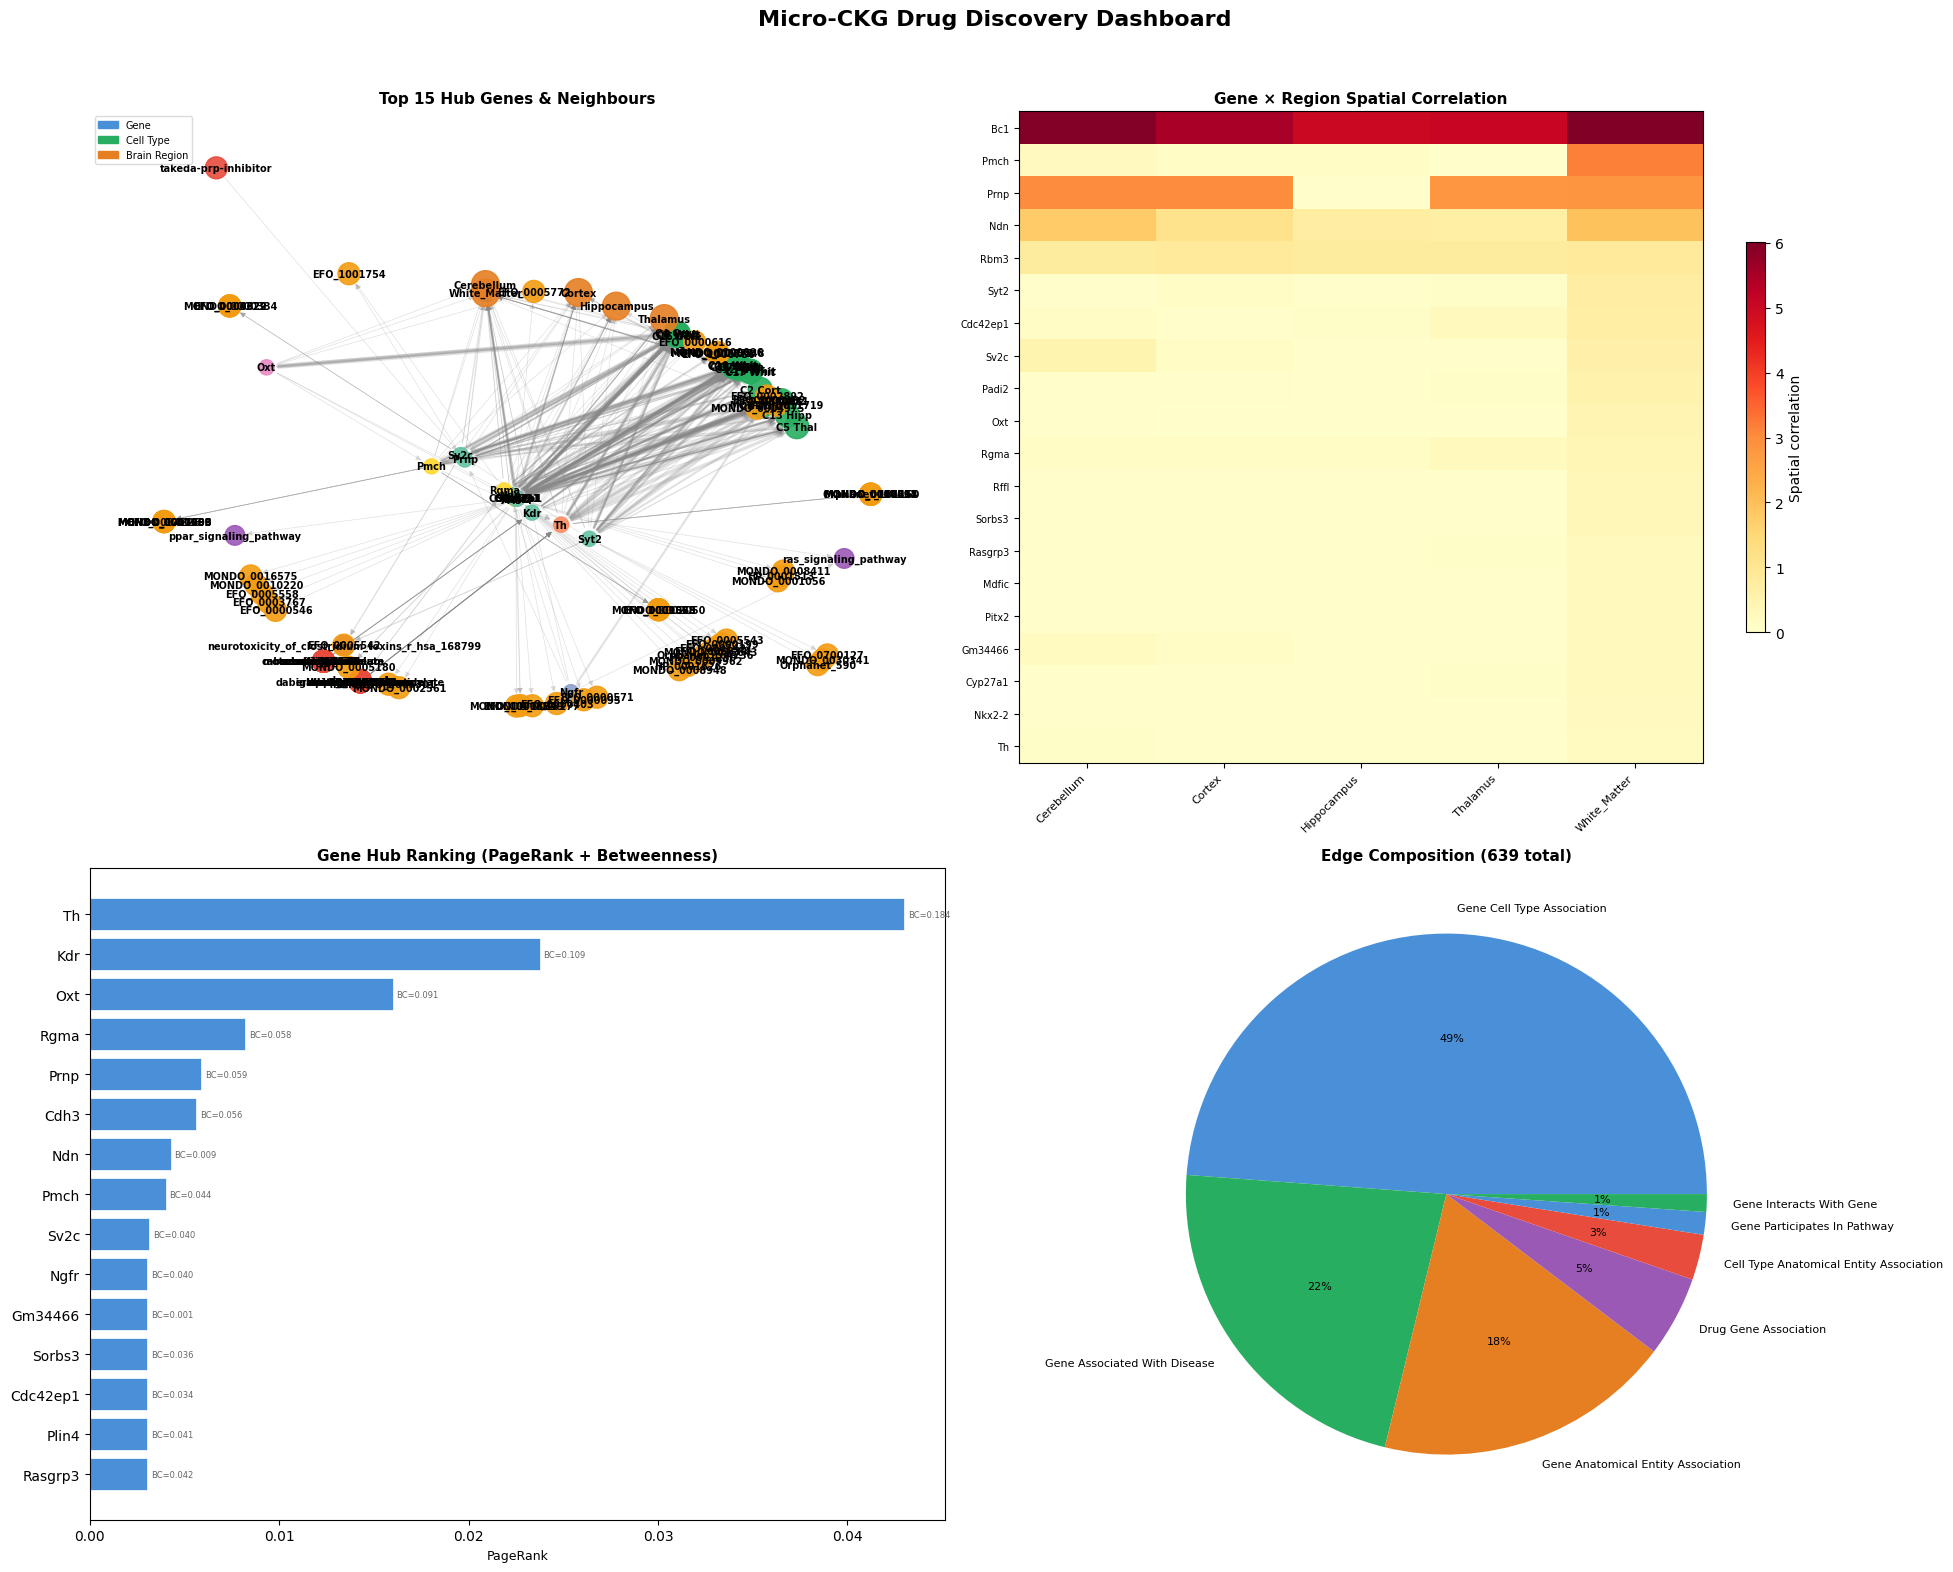

In [9]:
# Community detection & centrality
community_map = detect_communities(graph)
centrality_df = compute_centrality(graph)
bridge_df = find_bridge_genes(graph, centrality_df)

print("Top 10 hub genes by PageRank:")
gene_centrality = centrality_df[centrality_df["label"] == "gene"].head(10)
print(gene_centrality[["degree", "betweenness", "pagerank"]].to_string())

print("\nBridge genes (connect multiple graph communities):")
print(bridge_df.head(10)[["gene", "bridge_score", "n_communities_bridged", "betweenness"]].to_string(index=False))

# Multi-panel drug discovery dashboard
visualize_graph(graph, community_map=community_map, centrality_df=centrality_df)

## 4.7 Save Graph

The Micro-CKG is serialized to GraphML format, a standard XML-based graph format supported by NetworkX, Cytoscape, Neo4j, and other graph analysis tools. This file serves as the input to the LLM agent in Step 05 and can also be loaded into graph visualization software for interactive exploration.

In [10]:
graph_path = save_graph(graph, CACHE_DIR / "micro_ckg.graphml")
print(f"\nGraph persisted: {graph_path}")
print(f"File size: {graph_path.stat().st_size / 1e3:.1f} KB")

  Graph saved to /Users/shaunfchen/Documents/Repositories/spatial-microckg-agent/cache/micro_ckg.graphml

Graph persisted: /Users/shaunfchen/Documents/Repositories/spatial-microckg-agent/cache/micro_ckg.graphml
File size: 298.7 KB


## 4.8 Spatial Validation (Moran's I)

**Why this matters for drug development:** A biomarker is only therapeutically relevant if its spatial expression pattern is non-random. Moran's I > 0 with p < 0.05 confirms that a gene shows **spatially clustered expression** — it marks a real tissue compartment, not noise. This spatial specificity is critical for targeted drug delivery.

In [11]:
# Build spatial neighbourhood graph
adata = compute_spatial_neighbors(adata, n_neighs=6)

# Spatial autocorrelation — test Stabl-selected genes
moran_df = compute_spatial_autocorr(
    adata,
    genes=stabl_result["selected_genes"],
    mode="moran",
    n_perms=100,
)

# Show top spatially autocorrelated genes
sig_moran = moran_df[moran_df["pval_norm"] < 0.05].sort_values("I", ascending=False)
print(f"\nTop spatially autocorrelated Stabl genes (Moran's I):")
print(f"({len(sig_moran)}/{len(stabl_result['selected_genes'])} genes spatially significant)\n")
print(sig_moran.head(15)[["I", "pval_norm"]].to_string())

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


  Spatial neighbours computed (n_neighs=6)


  0%|          | 0/100 [00:00<?, ?/s]

python3(35906) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


  1%|          | 1/100 [00:03<05:38,  3.41s/]

...

 92%|█████████▏| 92/100 [00:06<00:00, 30.54/s]

 96%|█████████▌| 96/100 [00:06<00:00, 30.90/s]

100%|██████████| 100/100 [00:06<00:00, 30.95/s]

100%|██████████| 100/100 [00:06<00:00, 15.25/s]

  Spatial autocorrelation (moran): 31/33 genes significant (p < 0.05)

Top spatially autocorrelated Stabl genes (Moran's I):
(31/33 genes spatially significant)

                 I  pval_norm
Ndn       0.216005        0.0
Pmch      0.163190        0.0
Gm34466   0.150658        0.0
Syt2      0.144329        0.0
Pitx2     0.143883        0.0
Cfap221   0.131560        0.0
Cdc42ep1  0.111123        0.0
Sv2c      0.093586        0.0
Padi2     0.090450        0.0
Th        0.088262        0.0
Sorbs3    0.062861        0.0
Cyp27a1   0.053245        0.0
Rffl      0.052489        0.0
Rbm3      0.048351        0.0
Nkx2-2    0.047853        0.0


## 4.9 Translational Context Sub-Graph (Diseases, Drugs, Pathways)

Force-directed network of Stabl-certified genes and their
translational biological context. Only the **top 15 diseases**
(by OpenTargets association score) are shown alongside all
connected pathways and drugs.

| Colour | Shape | Node type | Source |
|---|---|---|---|
| **Blue** | circle | Gene | Stabl-selected biomarker |
| **Purple** | diamond | Pathway | Enrichr (GO / KEGG / Reactome) |
| **Red** | triangle | Disease | OpenTargets Platform |
| **Teal** | square | Drug | ChEMBL |

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


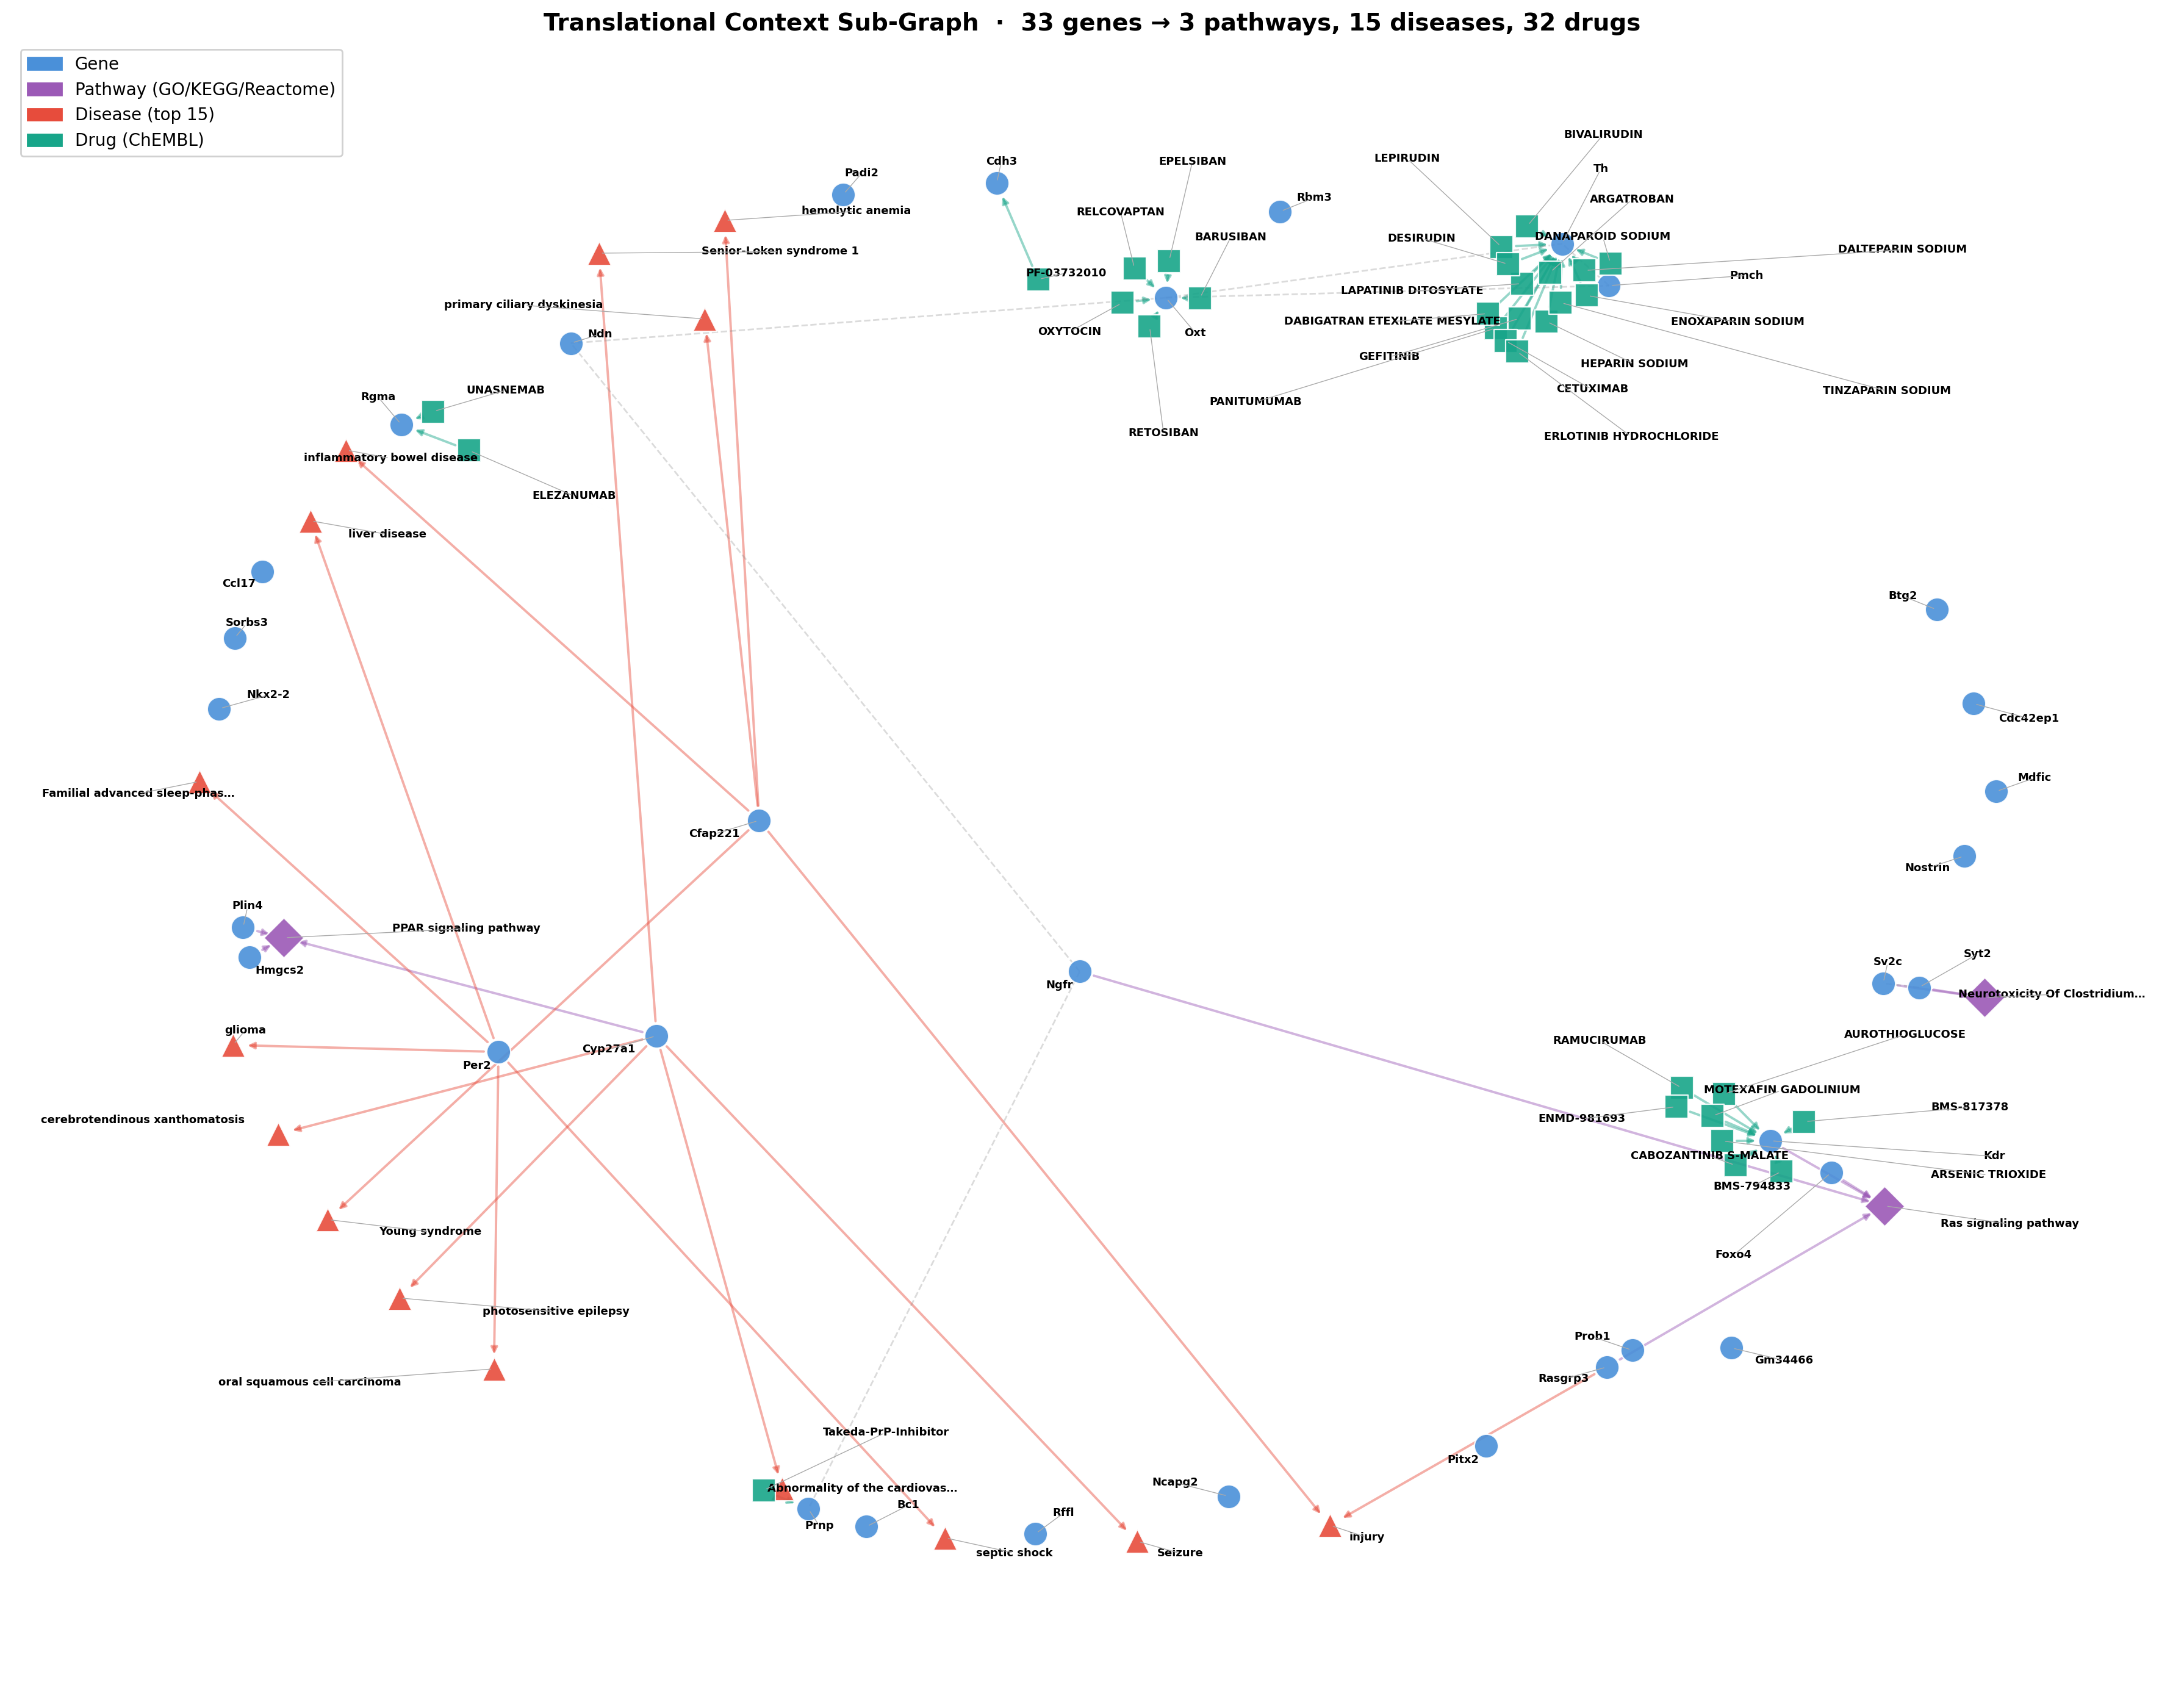

Sub-graph: 83 nodes, 64 edges
  Blue (genes): 33  |  Purple (pathways): 3  |  Red (diseases): 15  |  Teal (drugs): 32
  (Showing top 15 of 119 disease associations by OpenTargets score)


In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import networkx as nx
from adjustText import adjust_text

_MAX_DISEASES = 15

_VIS_COLORS = {
    "gene": "#4A90D9",
    "biological_process": "#9B59B6",
    "disease": "#E74C3C",
    "drug": "#17A589",
}
_MARKERS = {
    "gene": "o",
    "biological_process": "D",
    "disease": "^",
    "drug": "s",
}
_EDGE_COLORS = {
    "gene_participates_in_pathway": "#9B59B6",
    "gene_associated_with_disease": "#E74C3C",
    "drug_gene_association": "#17A589",
    "gene_interacts_with_gene": "#888888",
}

def _display(n: str) -> str:
    nd = graph.nodes[n]
    lbl = nd.get("label", "")
    if lbl in ("disease", "drug", "biological_process"):
        name = nd.get("name", str(n).split(":", 1)[-1])
    else:
        name = nd.get("symbol", str(n).split(":", 1)[-1])
    return name[:28] + "\u2026" if len(name) > 30 else name

# ---- node sets ----
core_gene_nodes = {
    f"gene:{g}" for g in stabl_result["selected_genes"]
} & set(graph.nodes())

connected_pathways = {
    v for u, v in graph.edges()
    if u in core_gene_nodes
    and graph.nodes[v].get("label") == "biological_process"
}
connected_drugs = {
    u for u, v in graph.edges()
    if v in core_gene_nodes
    and graph.nodes[u].get("label") == "drug"
}
_all_disease_edges = [
    (u, v, d) for u, v, d in graph.edges(data=True)
    if u in core_gene_nodes
    and graph.nodes[v].get("label") == "disease"
]
_disease_scores: dict[str, float] = {}
for _, v, d in _all_disease_edges:
    _disease_scores[v] = max(_disease_scores.get(v, 0.0), d.get("score", 0.0))
top_diseases = set(
    sorted(_disease_scores, key=_disease_scores.get, reverse=True)[:_MAX_DISEASES]
)

focused_nodes = core_gene_nodes | connected_pathways | top_diseases | connected_drugs
sub = graph.subgraph(focused_nodes).copy()

# ---- force-directed layout (spring = Fruchterman-Reingold) ----
# k controls inter-node repulsion; higher = more spread out
pos = nx.spring_layout(sub, k=3.0 / np.sqrt(max(sub.number_of_nodes(), 1)),
                       iterations=200, seed=42)

# ---- group nodes by type for per-marker drawing ----
_node_groups: dict[str, list[str]] = {}
for n in sub.nodes():
    lbl = sub.nodes[n].get("label", "gene")
    _node_groups.setdefault(lbl, []).append(n)

# ---- edge groups ----
solid_edges, solid_colors = [], []
dashed_edges = []
for u, v, d in sub.edges(data=True):
    el = d.get("label", "")
    if el == "gene_interacts_with_gene":
        dashed_edges.append((u, v))
    else:
        solid_edges.append((u, v))
        solid_colors.append(_EDGE_COLORS.get(el, "#CCCCCC"))

# ---- figure ----
fig, ax = plt.subplots(figsize=(18, 14))

# edges first
if solid_edges:
    nx.draw_networkx_edges(sub, pos, edgelist=solid_edges, ax=ax,
                           edge_color=solid_colors, alpha=0.45,
                           arrows=True, arrowsize=8, width=1.4)
if dashed_edges:
    nx.draw_networkx_edges(sub, pos, edgelist=dashed_edges, ax=ax,
                           edge_color="#888888", alpha=0.30,
                           style="dashed", arrows=False, width=1.0)

# nodes by type (separate draw calls for distinct markers)
_sizes = {"gene": 200, "biological_process": 280, "disease": 200, "drug": 180}
for lbl, nodes in _node_groups.items():
    nx.draw_networkx_nodes(
        sub, pos, nodelist=nodes, ax=ax,
        node_color=_VIS_COLORS.get(lbl, "#999"),
        node_shape=_MARKERS.get(lbl, "o"),
        node_size=_sizes.get(lbl, 400),
        alpha=0.90, edgecolors="white", linewidths=0.8,
    )

# labels — auto-positioned with adjustText to avoid overlaps
node_labels = {n: _display(n) for n in sub.nodes()}
_texts = []
for n in sub.nodes():
    x, y = pos[n]
    _texts.append(ax.text(x, y, node_labels[n],
                          fontsize=6.5, fontweight="bold",
                          ha="center", va="center"))
adjust_text(_texts, ax=ax,
            arrowprops=dict(arrowstyle="-", color="#AAAAAA", lw=0.5),
            expand=(1.8, 2.0),
            force_text=(0.8, 1.0),
            force_points=(0.4, 0.5))

legend_handles = [
    mpatches.Patch(color=_VIS_COLORS["gene"], label="Gene"),
    mpatches.Patch(color=_VIS_COLORS["biological_process"],
                   label="Pathway (GO/KEGG/Reactome)"),
    mpatches.Patch(color=_VIS_COLORS["disease"],
                   label=f"Disease (top {_MAX_DISEASES})"),
    mpatches.Patch(color=_VIS_COLORS["drug"], label="Drug (ChEMBL)"),
]
ax.legend(handles=legend_handles, loc="upper left",
          fontsize=10, framealpha=0.90)

n_genes = len(core_gene_nodes & set(sub.nodes()))
n_pw = len(connected_pathways & set(sub.nodes()))
n_dis = len(top_diseases & set(sub.nodes()))
n_drg = len(connected_drugs & set(sub.nodes()))
ax.set_title(
    f"Translational Context Sub-Graph  \u00b7  "
    f"{n_genes} genes \u2192 {n_pw} pathways, "
    f"{n_dis} diseases, {n_drg} drugs",
    fontsize=14, fontweight="bold",
)
ax.axis("off")
plt.tight_layout()

out_path = CACHE_DIR / "bio_context_subgraph.png"
fig.savefig(out_path, dpi=200, bbox_inches="tight")
plt.close(fig)

from IPython.display import Image, display
display(Image(filename=str(out_path), width=950))
print(
    f"Sub-graph: {sub.number_of_nodes()} nodes, "
    f"{sub.number_of_edges()} edges"
)
print(
    f"  Blue (genes): {n_genes}  |  "
    f"Purple (pathways): {n_pw}  |  "
    f"Red (diseases): {n_dis}  |  "
    f"Teal (drugs): {n_drg}"
)
if len(_disease_scores) > _MAX_DISEASES:
    print(
        f"  (Showing top {_MAX_DISEASES} of {len(_disease_scores)} "
        f"disease associations by OpenTargets score)"
    )

## 4.10 Presentation-Grade Subgraph — Top AD Hub Genes

This cell draws a **clean, filtered subgraph** focused on the three
highest-impact genes in the Micro-CKG, selected by a combination of
network degree, drug connectivity, and direct AD-disease relevance:

| Gene | AD relevance | Why it matters |
|---|---|---|
| **Prnp** | Aβ synaptic toxicity | PrP^C is the primary neuronal receptor for Aβ oligomers; its KG neighbourhood reveals Takeda-PrP-Inhibitor and prion-disease associations |
| **Th** | Monoaminergic neurodegeneration | Highest-degree gene in the KG (40 edges, 15 drugs); TH loss marks locus coeruleus degeneration, one of the earliest AD events |
| **Ngfr** | Aβ-mediated apoptosis | p75^NTR mediates Aβ-induced neuronal death; links to Ras signalling and broad neurodegenerative disease associations |

Only edges with |log2FC| > 0.25, spatial correlation > 0.5, or
translational context (pathway/disease/drug) are retained.

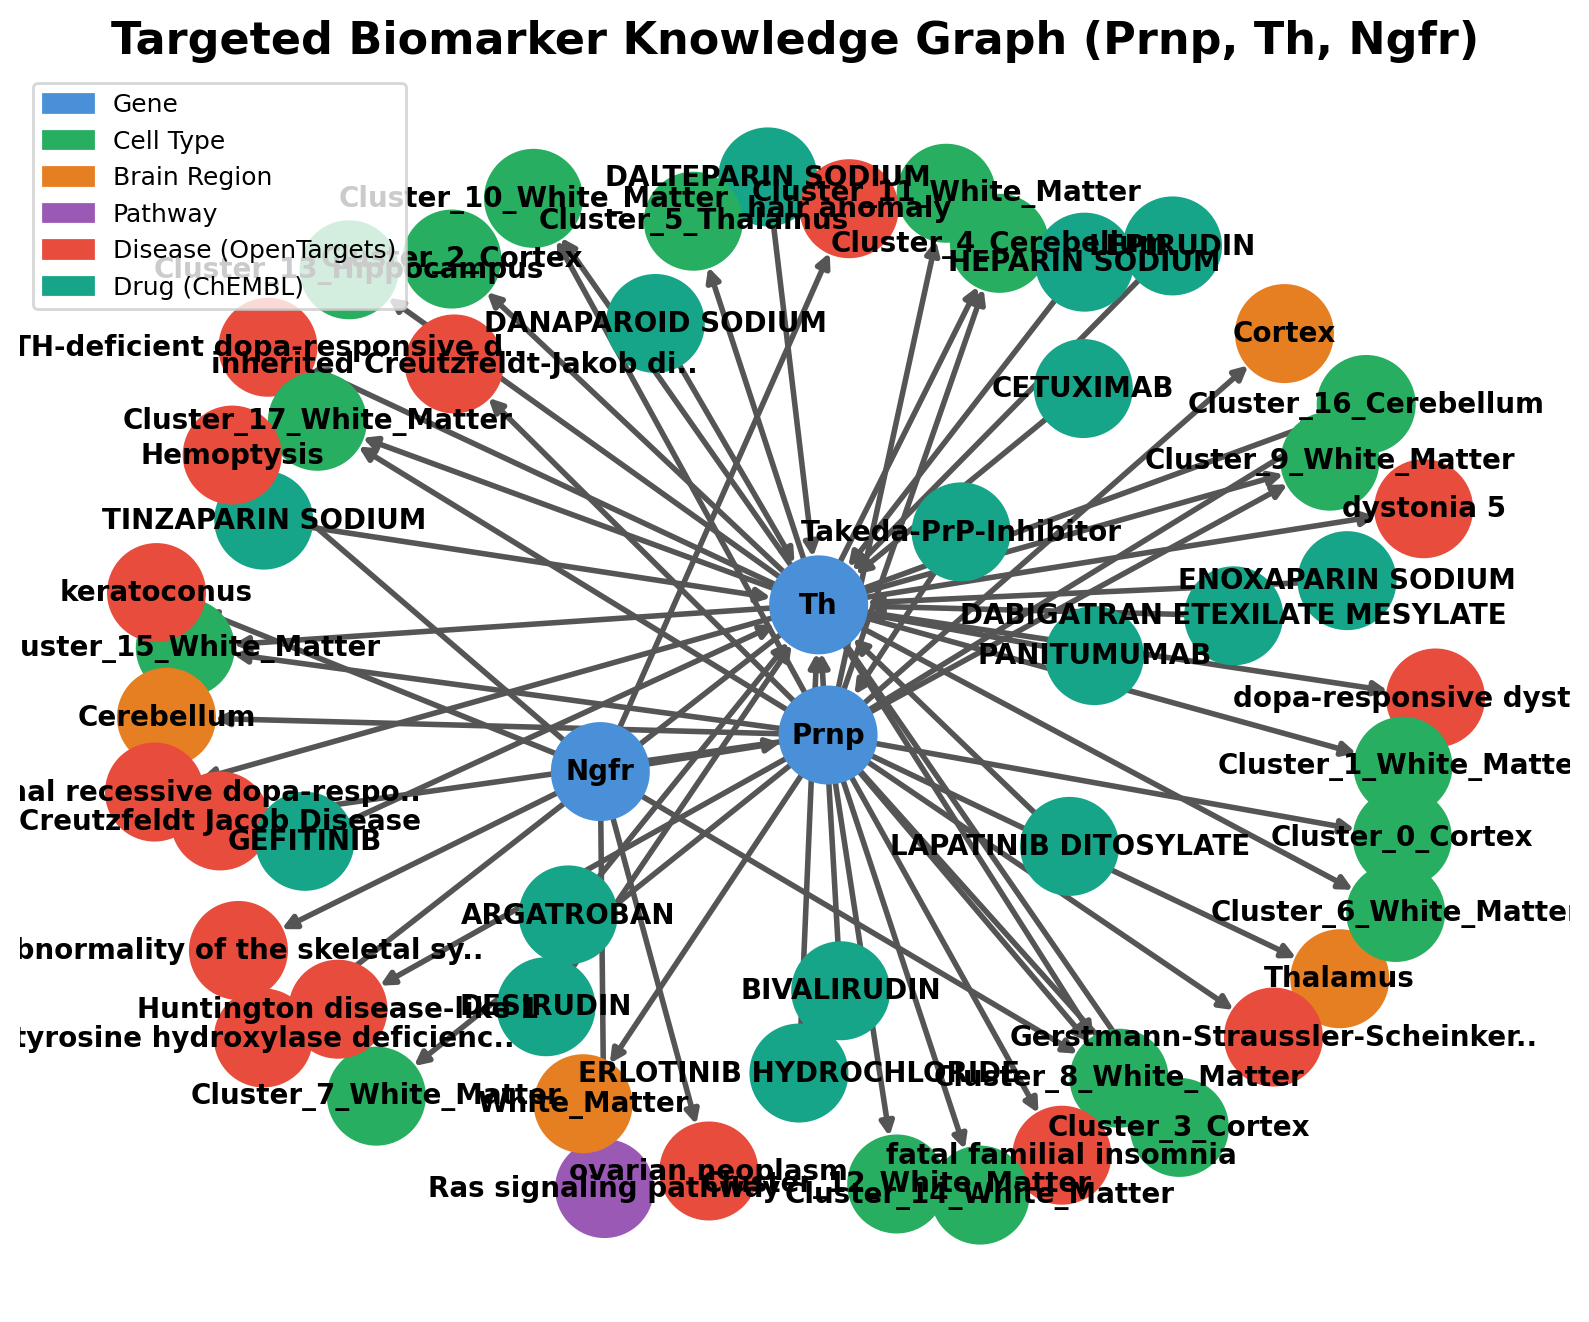

Subgraph: 57 nodes, 64 edges


In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

key_genes = ["gene:Prnp", "gene:Th", "gene:Ngfr"]
presentation_nodes = set(key_genes)
presentation_edges = []

# DE / spatial proximity edges
for u, v, d in graph.edges(data=True):
    if u in key_genes and (
        abs(d.get("log2fc", 0)) > 0.25 or d.get("spatial_correlation", 0) > 0.5
    ):
        presentation_nodes.add(v)
        presentation_edges.append((u, v))

# Biological context edges (pathway / disease / drug)
for u, v, d in graph.edges(data=True):
    if u in key_genes and d.get("label") in (
        "gene_participates_in_pathway",
        "gene_associated_with_disease",
    ):
        presentation_nodes.add(v)
        presentation_edges.append((u, v))
# Drug→gene edges (drugs are source, genes are target)
for u, v, d in graph.edges(data=True):
    if v in key_genes and d.get("label") == "drug_gene_association":
        presentation_nodes.add(u)
        presentation_edges.append((u, v))

# PPI edges among key genes
for u, v, d in graph.edges(data=True):
    if (
        d.get("label") == "gene_interacts_with_gene"
        and u in key_genes
        and v in key_genes
    ):
        presentation_nodes.update([u, v])
        presentation_edges.append((u, v))

sub = graph.subgraph(presentation_nodes).copy()
sub.remove_edges_from(
    [e for e in sub.edges() if e not in presentation_edges]
)

fig, ax = plt.subplots(figsize=(10, 8))
pos = nx.spring_layout(sub, k=0.8, seed=42)

_PRES_COLORS = {
    "gene": "#4A90D9",
    "cell_type": "#27AE60",
    "anatomical_entity": "#E67E22",
    "biological_process": "#9B59B6",
    "disease": "#E74C3C",
    "drug": "#17A589",
}
colors = [
    _PRES_COLORS.get(sub.nodes[n].get("label", ""), "#999999")
    for n in sub.nodes()
]
def _pres_label(n: str) -> str:
    d = sub.nodes[n]
    lbl = d.get("label", "")
    if lbl in ("disease", "drug", "biological_process"):
        name = d.get("name", str(n).split(":", 1)[-1])
    else:
        name = d.get("symbol", str(n).split(":", 1)[-1])
    return name[:30] + ".." if len(name) > 30 else name

labels = {n: _pres_label(n) for n in sub.nodes()}

nx.draw(sub, pos, ax=ax, with_labels=True, labels=labels, node_color=colors,
        node_size=1200, font_size=10, font_weight="bold",
        edge_color="#555", width=2.0)

present_labels = {sub.nodes[n].get("label", "") for n in sub.nodes()}
legend_handles = [
    mpatches.Patch(color=c, label=lname)
    for ltype, lname, c in [
        ("gene", "Gene", "#4A90D9"),
        ("cell_type", "Cell Type", "#27AE60"),
        ("anatomical_entity", "Brain Region", "#E67E22"),
        ("biological_process", "Pathway", "#9B59B6"),
        ("disease", "Disease (OpenTargets)", "#E74C3C"),
        ("drug", "Drug (ChEMBL)", "#17A589"),
    ]
    if ltype in present_labels
]
if legend_handles:
    ax.legend(handles=legend_handles, loc="upper left", fontsize=9, framealpha=0.8)

ax.set_title(
    "Targeted Biomarker Knowledge Graph (Prnp, Th, Ngfr)",
    fontsize=16, fontweight="bold",
)
out_path = CACHE_DIR / "presentation_subgraph.png"
fig.savefig(out_path, dpi=200, bbox_inches="tight")
plt.close(fig)

from IPython.display import Image, display
display(Image(filename=str(out_path), width=700))
print(f"Subgraph: {sub.number_of_nodes()} nodes, {sub.number_of_edges()} edges")